# Campos direccionales, isoclinas y método de Euler

**Ecuaciones Diferenciales Ordinarias I**

En este cuaderno usaremos Python para visualizar ecuaciones diferenciales de primer orden y aproximar sus soluciones. Ejecuta las celdas en orden con `Shift + Enter`.

## 1. Python: lo mínimo que necesitaremos

Una variable guarda un valor. Para calcular potencias se usa `**`. Los comentarios comienzan con `#`.

In [1]:
t = 2
y = 3 * t**2 - t + 1

print('t =', t)
print('y(t) =', y)

t = 2
y(t) = 11


In [3]:
def f(t, y):
    return t - y

print(f(2, 1))

1


La función anterior representa la ecuación diferencial $y'=t-y$. En Python, `def` sirve para definir funciones.

## 2. Bibliotecas: NumPy, Matplotlib y SciPy

- **NumPy** trabaja con arreglos numéricos y funciones como $e^t$, seno y coseno.
- **Matplotlib** crea gráficas.
- **SciPy** incluye métodos numéricos ya implementados.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

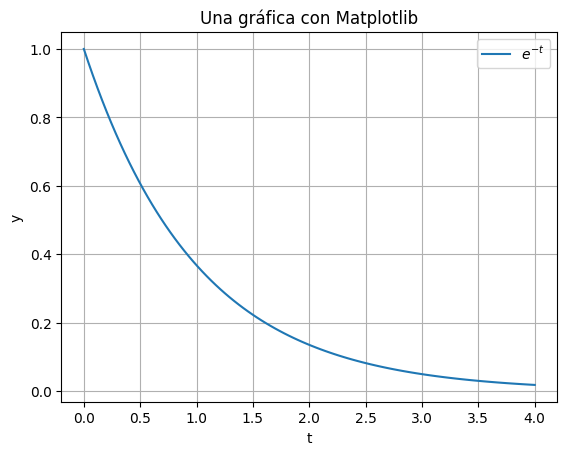

In [5]:
t = np.linspace(0, 4, 100)
y = np.exp(-t)

plt.plot(t, y, label=r'$e^{-t}$')
plt.xlabel('t')
plt.ylabel('y')
plt.title('Una gráfica con Matplotlib')
plt.grid()
plt.legend()
plt.show()

## 3. Campos direccionales

Para una ecuación $y'=f(x,y)$, en cada punto $(x,y)$ la pendiente de una curva solución es $f(x,y)$. Un campo direccional dibuja pequeños segmentos con esas pendientes.

In [6]:
def campo_direccional(f, xlim, ylim, n=20):
    x = np.linspace(xlim[0], xlim[1], n)
    y = np.linspace(ylim[0], ylim[1], n)
    X, Y = np.meshgrid(x, y)

    pendiente = f(X, Y)
    longitud = np.sqrt(1 + pendiente**2)
    U = 1 / longitud
    V = pendiente / longitud

    plt.quiver(X, Y, U, V, angles='xy', scale_units='xy', scale=1)
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid()

### Ejemplo 1: $y'=x-y$

La pendiente es positiva si $x>y$, nula si $x=y$, y negativa si $x<y$.

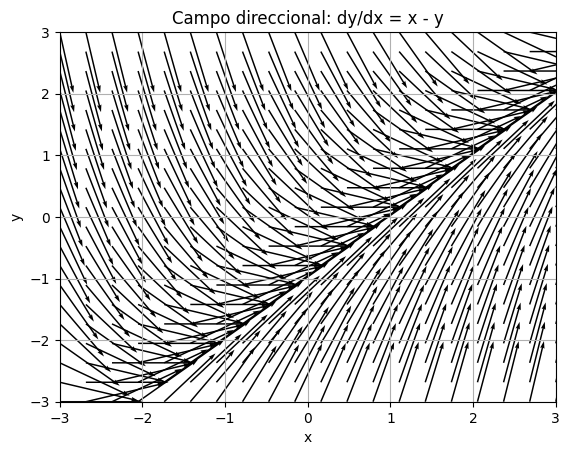

In [7]:
def f1(x, y):
    return x - y

campo_direccional(f1, xlim=(-3, 3), ylim=(-3, 3))
plt.title('Campo direccional: dy/dx = x - y')
plt.show()

### Campo y curvas solución exactas

Para la ecuación $y'=x-y$, la solución general es

$$y=x-1+C e^{-x}.$$

Cada valor de $C$ produce una curva solución distinta. Las curvas deben ser tangentes a los segmentos del campo en todos sus puntos.

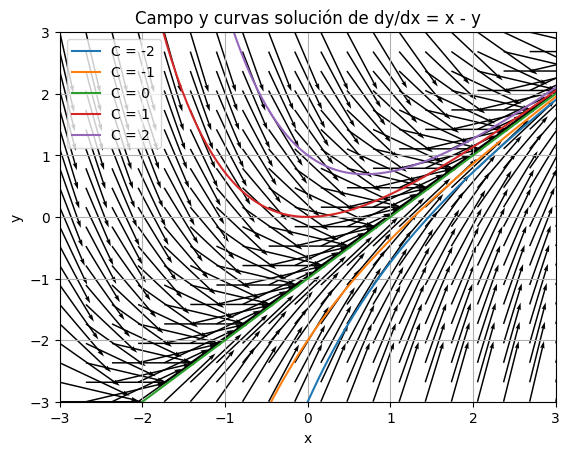

In [8]:
def solucion_exacta(x, C):
    return x - 1 + C * np.exp(-x)

campo_direccional(f1, xlim=(-3, 3), ylim=(-3, 3))

x = np.linspace(-3, 3, 200)
for C in [-2, -1, 0, 1, 2]:
    plt.plot(x, solucion_exacta(x, C), label=f'C = {C}')

plt.title('Campo y curvas solución de dy/dx = x - y')
plt.legend()
plt.show()

### Otro ejemplo: modelo logístico $y'=y(1-y)$

Observa los equilibrios $y=0$ y $y=1$. Las pendientes no dependen de $x$.

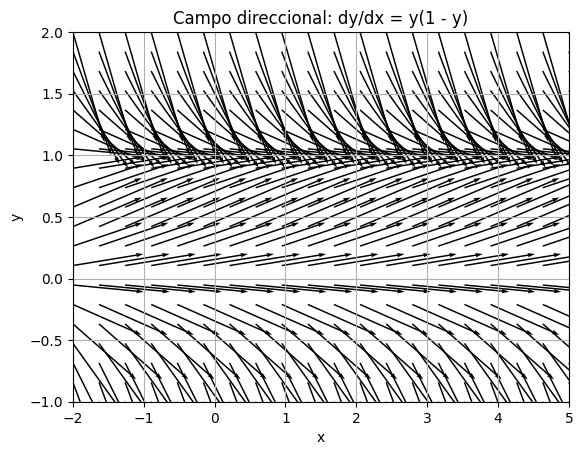

In [9]:
def f_logistica(x, y):
    return y * (1 - y)

campo_direccional(f_logistica, xlim=(-2, 5), ylim=(-1, 2))
plt.title('Campo direccional: dy/dx = y(1 - y)')
plt.show()

### Actividad 1

Considera la ecuación diferencial

$$y'=xy-x=x(y-1).$$

**Paso 1. Campo direccional.** Completa la función `f_actividad` y ejecuta la gráfica. Identifica dónde la pendiente es cero.

**Paso 2. Soluciones analíticas.** Resuelve la ecuación por separación de variables. Recuerda el Problema 1 de la Tarea 2: al dividir, revisa si hay soluciones constantes que deban conservarse. Después completa `solucion_analitica` y la instrucción `plt.plot` para dibujar varias curvas solución sobre el mismo campo.

In [10]:
def f_actividad(x, y):
    # Escribe aquí la expresión para x * y - x
    pass

# campo_direccional(f_actividad, xlim=(-2, 2), ylim=(-4, 4))
# plt.title('Campo direccional de la actividad')
# plt.show()

In [11]:
def solucion_analitica(x, C):
    # Escribe aquí la familia de soluciones que obtuviste.
    pass

campo_direccional(f_actividad, xlim=(-2, 2), ylim=(-4, 4))

x = np.linspace(-2, 2, 200)
for C in [-1, -0.5, 0, 0.5, 1]:
    # Completa esta línea con plt.plot(x, solucion_analitica(...)).
    pass

plt.title('Campo y soluciones de la actividad')
plt.grid()
plt.show()

TypeError: unsupported operand type(s) for ** or pow(): 'NoneType' and 'int'

## 4. Isoclinas

Una **isoclina** es una curva donde la pendiente tiene un valor constante $c$: $f(x,y)=c$.

Para $y'=x-y$, las isoclinas cumplen $x-y=c$, o equivalentemente $y=x-c$. Sobre cada una, los segmentos del campo tienen la misma inclinación.

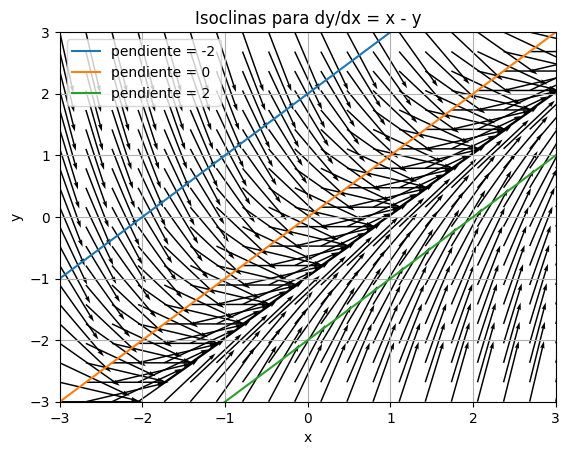

In [13]:
campo_direccional(f1, xlim=(-3, 3), ylim=(-3, 3))

x = np.linspace(-3, 3, 100)
for c in [-2, 0, 2]:
    plt.plot(x, x - c, label=f'pendiente = {c}')

plt.title('Isoclinas para dy/dx = x - y')
plt.legend()
plt.show()

### Actividad 2

Para $y'=y(1-y)$, encuentra las isoclinas de pendiente $0$, $1/4$ y $-2$. Haz una gráfica que muestre el campo y las isoclinas que obtengas.

In [ ]:
# Escribe tu desarrollo aquí.
# Sugerencia: resuelve y * (1 - y) = c para cada valor de c.

## 5. Método de Euler

Si conocemos un punto $(t_n,y_n)$ y usamos un paso $h$, el método de Euler aproxima el siguiente punto mediante

$$t_{n+1}=t_n+h, \qquad y_{n+1}=y_n+h f(t_n,y_n).$$

Es una aproximación: en cada paso seguimos la recta tangente.

In [14]:
def euler(f, t0, y0, h, pasos):
    t = [t0]
    y = [y0]

    for _ in range(pasos):
        siguiente_y = y[-1] + h * f(t[-1], y[-1])
        siguiente_t = t[-1] + h
        t.append(siguiente_t)
        y.append(siguiente_y)

    return np.array(t), np.array(y)

### Ejemplo 1: $y'=3+e^{-t} \frac{1}{2}y$, $y(0)=1$

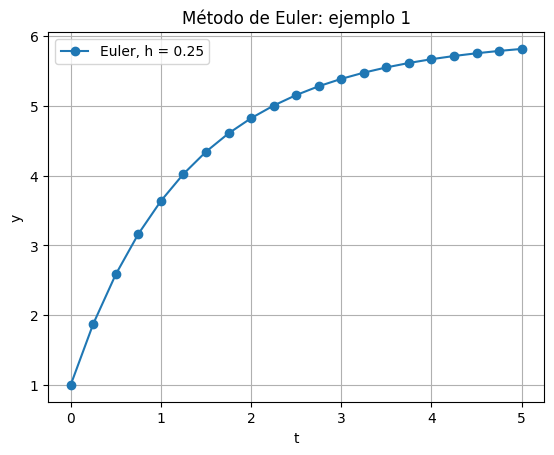

In [15]:
def ejemplo_1(t, y):
    return 3 + np.exp(-t) - 0.5 * y

t_euler, y_euler = euler(ejemplo_1, t0=0, y0=1, h=0.25, pasos=20)

plt.plot(t_euler, y_euler, 'o-', label='Euler, h = 0.25')
plt.xlabel('t')
plt.ylabel('y')
plt.title('Método de Euler: ejemplo 1')
plt.grid()
plt.legend()
plt.show()

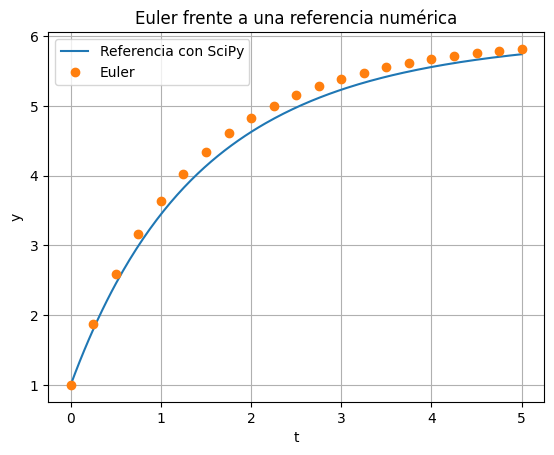

In [16]:
solucion_scipy = solve_ivp(ejemplo_1, [0, 5], [1], dense_output=True)
t = np.linspace(0, 5, 200)

plt.plot(t, solucion_scipy.sol(t)[0], label='Referencia con SciPy')
plt.plot(t_euler, y_euler, 'o', label='Euler')
plt.xlabel('t')
plt.ylabel('y')
plt.title('Euler frente a una referencia numérica')
plt.grid()
plt.legend()
plt.show()

SciPy nos da una aproximación numérica de referencia. No sustituye el análisis matemático ni el método de Euler; aquí solo nos ayuda a comparar resultados.

### Ejemplo 2: $y'=4-t+2y$, $y(0)=1$

Cambia el tamaño de paso y compara las gráficas. ¿Qué observas al usar $h=0.5$ y $h=0.1$?

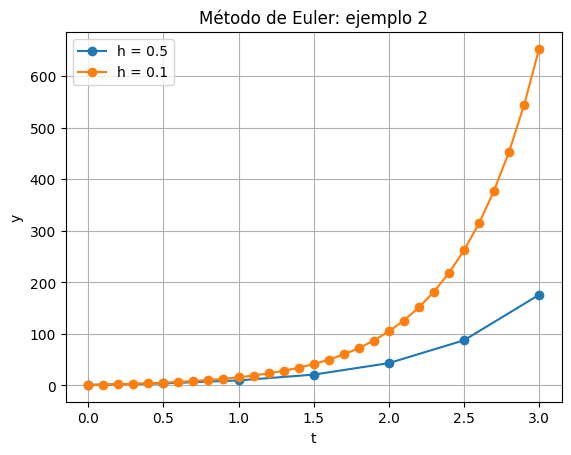

In [17]:
def ejemplo_2(t, y):
    return 4 - t + 2 * y

t_grande, y_grande = euler(ejemplo_2, t0=0, y0=1, h=0.5, pasos=6)
t_pequeno, y_pequeno = euler(ejemplo_2, t0=0, y0=1, h=0.1, pasos=30)

plt.plot(t_grande, y_grande, 'o-', label='h = 0.5')
plt.plot(t_pequeno, y_pequeno, 'o-', label='h = 0.1')
plt.xlabel('t')
plt.ylabel('y')
plt.title('Método de Euler: ejemplo 2')
plt.grid()
plt.legend()
plt.show()

### Actividad 3

Completa la aplicación del método de Euler para

$$y'=3\cos(t)-2y, \qquad y(0)=1.$$

Usa primero $h=0.25$ hasta $t=4$. Después prueba otro tamaño de paso y explica cuál aproximación esperarías que sea más precisa.

In [ ]:
def actividad_euler(t, y):
    # Escribe aquí 3 cos(t) - 2y
    pass

# t, y = euler(actividad_euler, t0=0, y0=1, h=0.25, pasos=16)
# plt.plot(t, y, 'o-')
# plt.grid()
# plt.show()

## Para cerrar

1. Un campo direccional muestra la pendiente que tendría una solución en cada punto.
2. Las isoclinas agrupan puntos con la misma pendiente.
3. Euler construye una aproximación paso a paso usando rectas tangentes.

Antes de entregar una actividad, verifica que cada gráfica tenga ejes, título, cuadrícula y, cuando haya más de una curva, leyenda.